# Notebook 07 — Cross-Subject RSA and NeuroAI Geometry
**Pipeline position:** Geometry (02) → **RSA / NeuroAI (07)** → Extended Analysis (08)

**Input:** `results/02_geometry_{subj}.npz`  
**Output:** `results/07_rsa_results.json`

Analyses:
1. **Cross-subject RSA:** Are manifold geometries consistent across the four subjects?
2. **Model-brain comparison:** Load-distance model vs. observed RDM (Spearman ρ vs. noise ceiling).
3. **Procrustes + CKA alignment:** Quantify cross-subject similarity after orthogonal alignment.
4. **Load-dependent variability:** Is 2-back geometry more stereotyped than 0-back across subjects?

**References:** Kriegeskorte & Kievit (2013) *Trends Cogn Sci*; Kornblith et al. (2019) *ICML*; Nili et al. (2014) *PLoS Comput Biol*.


In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path("../src")))

from geometry import representational_dissimilarity_matrix, rsa_compare, subspace_overlap
from neuroai import (
    centered_kernel_alignment, procrustes_align,
    noise_ceiling_rsa, cross_subject_rsa,
)
from preprocessing import SUBJECTS
from visualization import nature_style, PALETTE, save_figure

nature_style()
RESULTS     = Path("../results")
MAINT_WIN   = (0.3, 1.4)   # maintenance window (s)
LOAD_LEVELS = [0, 1, 2]

print(f"Subjects: {SUBJECTS}  |  maintenance window: {MAINT_WIN[0]}–{MAINT_WIN[1]} s")


Subjects: ['al', 'ca', 'cc', 'ug']  |  maintenance window: 0.3–1.4 s


In [2]:
# Load latent geometry from notebook 02 results
Z_maint_by_subj = {}   # {subj: (N_trials, k)} maintenance-window mean
labels_by_subj  = {}   # {subj: (N_trials,) task_id 0/1/2-back}

for subj in SUBJECTS:
    path = RESULTS / f"02_geometry_{subj}.npz"
    if not path.exists():
        print(f"[{subj}] geometry file missing — run notebook 02 first")
        continue
    geo   = np.load(path, allow_pickle=True)
    Z     = geo["Z"]       # (N_trials, T, k)
    times = geo["times"]
    maint_t = (times >= MAINT_WIN[0]) & (times <= MAINT_WIN[1])
    Z_maint_by_subj[subj] = Z[:, maint_t, :].mean(axis=1)  # (N_trials, k)
    labels_by_subj[subj]  = geo["task_id"]
    print(f"[{subj}] {Z.shape[0]} trials → maint mean {Z_maint_by_subj[subj].shape}")

SUBJECTS_OK = list(Z_maint_by_subj.keys())
print(f"\nSubjects loaded: {SUBJECTS_OK}")


[al] 150 trials → maint mean (150, 8)
[ca] 300 trials → maint mean (300, 8)
[cc] 300 trials → maint mean (300, 8)
[ug] 300 trials → maint mean (300, 8)

Subjects loaded: ['al', 'ca', 'cc', 'ug']


In [3]:
# Condition-mean latent vectors and per-subject RDMs
rdm_by_subj    = {}   # {subj: (N_cond, N_cond) RDM}
Z_cond_by_subj = {}   # {subj: (N_cond, k) condition means}

for subj in SUBJECTS_OK:
    Z      = Z_maint_by_subj[subj]   # (N_trials, k)
    labels = labels_by_subj[subj]
    Z_cond = np.array([
        Z[labels == load].mean(0)
        for load in LOAD_LEVELS
        if (labels == load).sum() > 0
    ])
    Z_cond_by_subj[subj] = Z_cond
    rdm_by_subj[subj]    = representational_dissimilarity_matrix(Z_cond, metric="correlation")
    print(f"[{subj}] RDM: {rdm_by_subj[subj].shape}")


[al] RDM: (3, 3)
[ca] RDM: (3, 3)
[cc] RDM: (3, 3)
[ug] RDM: (3, 3)


In [4]:
# Cross-subject RSA, noise ceiling, and load-distance model
if len(SUBJECTS_OK) >= 2:
    result = cross_subject_rsa(rdm_by_subj)
    print("Cross-subject RSA (pairwise Spearman ρ):")
    print(result["pairwise_r"].round(3))
    print(f"Mean pairwise ρ: {result['mean_pairwise_r']:.3f}")

    rdm_stack = np.stack([rdm_by_subj[s] for s in SUBJECTS_OK])
    nc_lower, nc_upper = noise_ceiling_rsa(rdm_stack)
    print(f"Noise ceiling: [{nc_lower:.3f}, {nc_upper:.3f}]")

    n_cond     = list(rdm_by_subj.values())[0].shape[0]
    loads      = np.array(LOAD_LEVELS[:n_cond])
    mean_rdm   = np.mean(list(rdm_by_subj.values()), axis=0)
    model_load = np.abs(loads[:, None] - loads[None, :]) / 2.0
    rsa_load   = rsa_compare(mean_rdm, model_load)
    print(f"Load-distance model RSA ρ: {rsa_load:.3f}")


Cross-subject RSA (pairwise Spearman ρ):
[[ 1.  -0.5 -0.5 -0.5]
 [-0.5  1.  -0.5 -0.5]
 [-0.5 -0.5  1.   1. ]
 [-0.5 -0.5  1.   1. ]]
Mean pairwise ρ: -0.250
Noise ceiling: [0.125, 0.250]
Load-distance model RSA ρ: 1.000


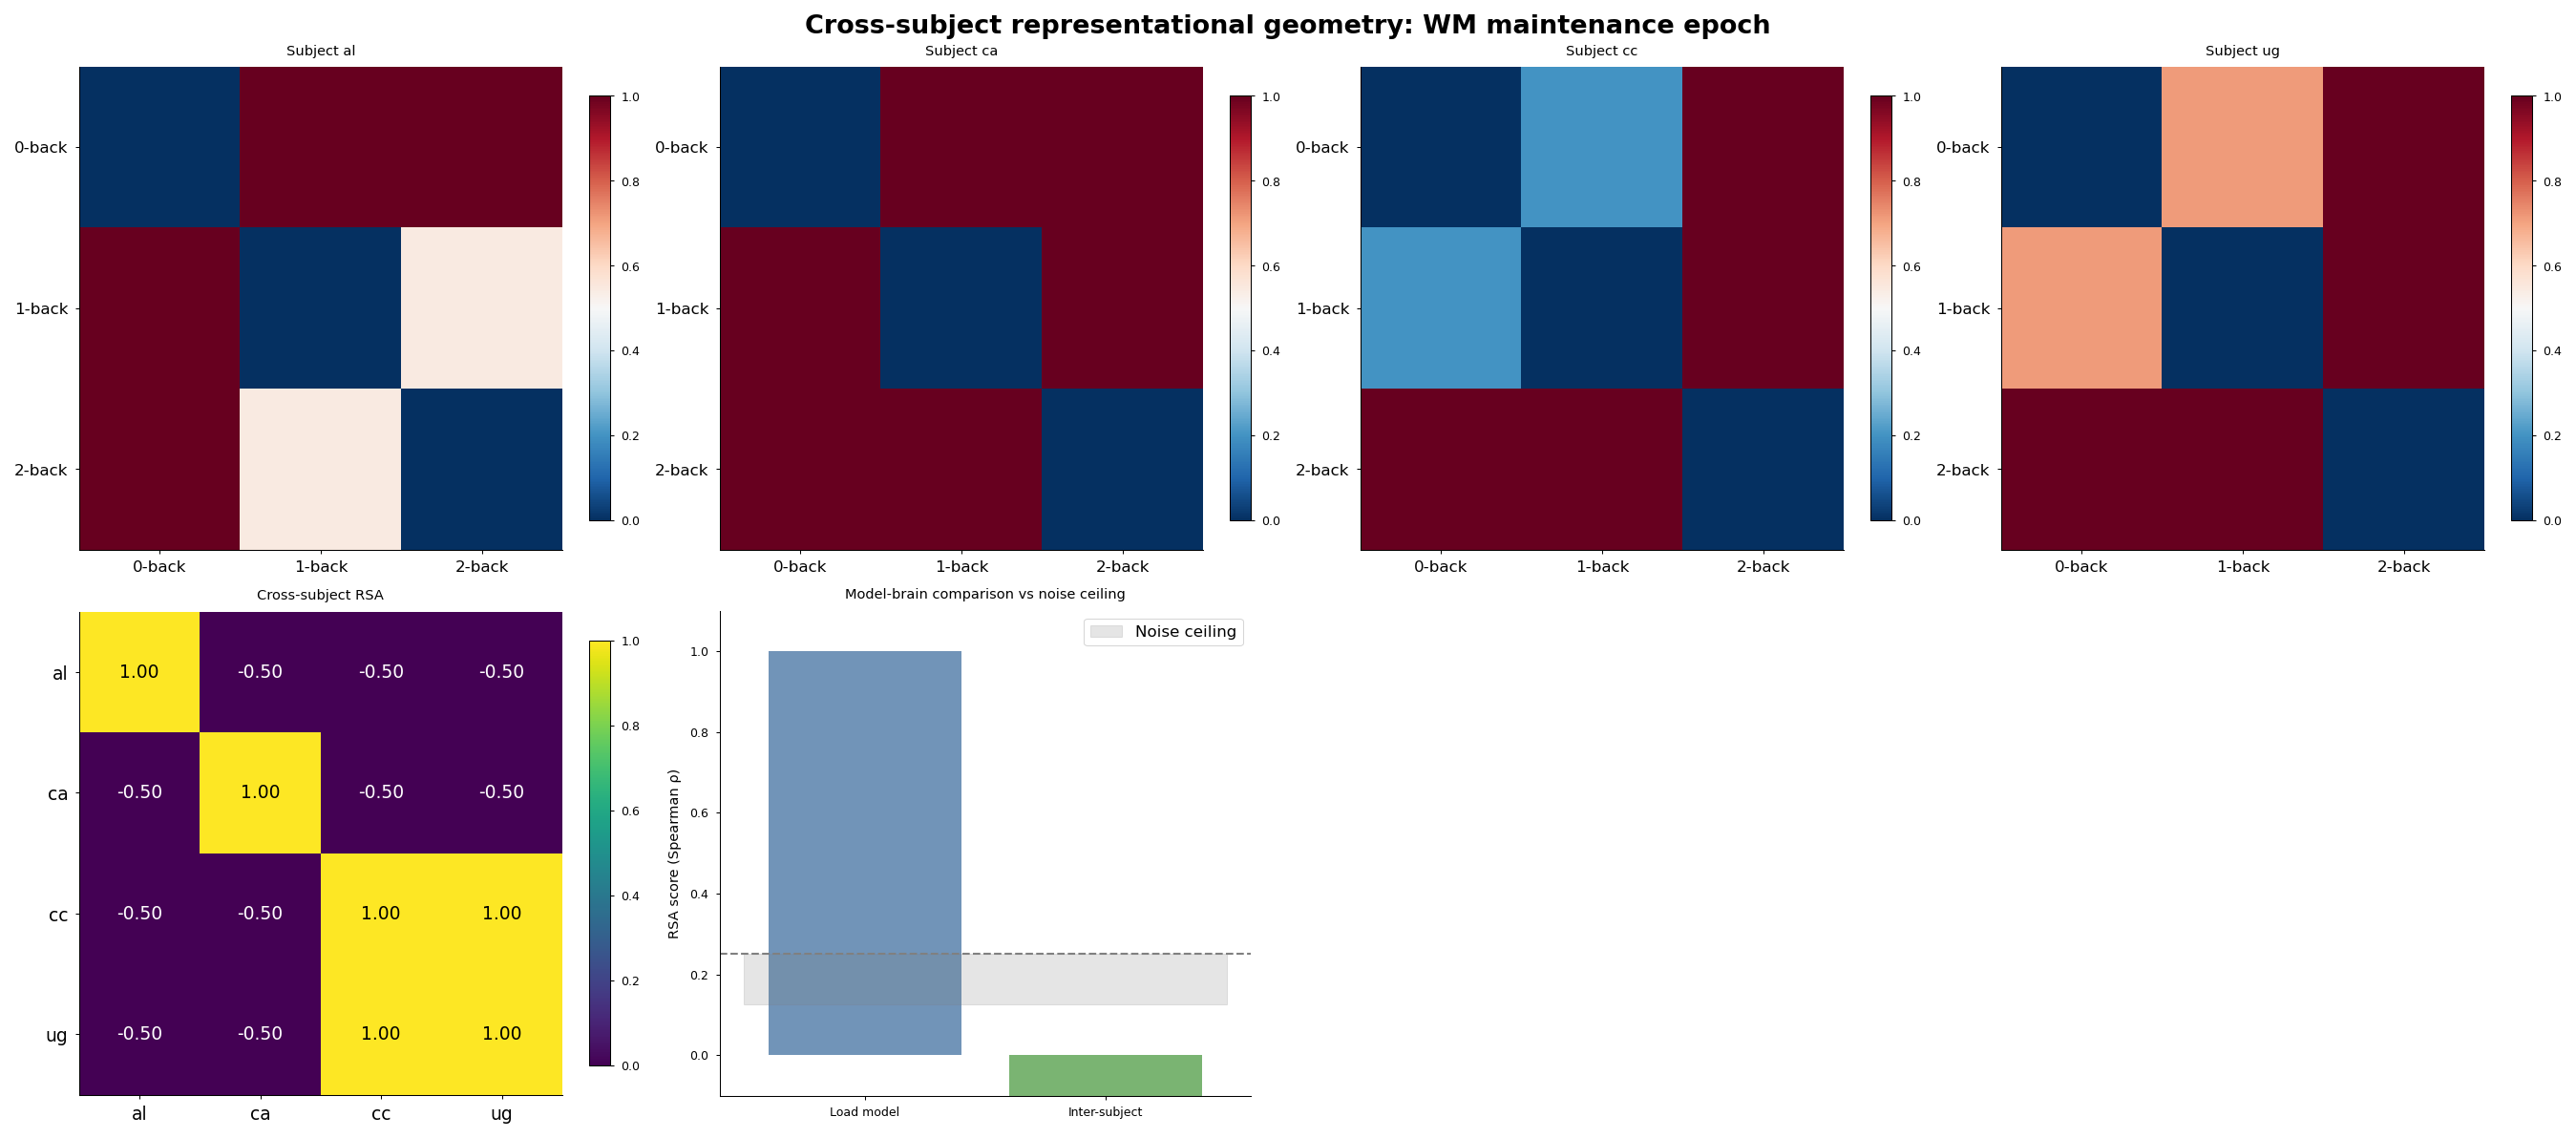

In [5]:
# ── Visualise RDMs ──
N_subj = len(SUBJECTS_OK)
fig, axes = plt.subplots(2, max(N_subj, 2), figsize=(4 * max(N_subj, 2) + 2, 8))

load_labels_plot = [f'{l}-back' for l in LOAD_LEVELS[:list(rdm_by_subj.values())[0].shape[0]]]

for col, subj in enumerate(SUBJECTS_OK):
    ax = axes[0, col]
    rdm = rdm_by_subj[subj]
    im = ax.imshow(rdm, cmap='RdBu_r', vmin=0, vmax=1)
    ax.set_title(f'Subject {subj}')
    ax.set_xticks(range(len(load_labels_plot)))
    ax.set_xticklabels(load_labels_plot, fontsize=8)
    ax.set_yticks(range(len(load_labels_plot)))
    ax.set_yticklabels(load_labels_plot, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.04)

# Hide unused axes in top row
for col in range(N_subj, axes.shape[1]):
    axes[0, col].set_visible(False)

# Cross-subject RSA matrix
if len(SUBJECTS_OK) >= 2:
    ax = axes[1, 0]
    P = result['pairwise_r']
    im = ax.imshow(P, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(SUBJECTS_OK)))
    ax.set_xticklabels(SUBJECTS_OK, fontsize=9)
    ax.set_yticks(range(len(SUBJECTS_OK)))
    ax.set_yticklabels(SUBJECTS_OK, fontsize=9)
    ax.set_title('Cross-subject RSA')
    for i in range(len(SUBJECTS_OK)):
        for j in range(len(SUBJECTS_OK)):
            ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center',
                    color='white' if P[i,j] < 0.5 else 'black', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.04)

    # Model comparison bar chart
    ax = axes[1, 1]
    mean_rdm = np.mean(list(rdm_by_subj.values()), axis=0)
    n_cond = mean_rdm.shape[0]
    # Load-only model: distance proportional to load difference
    loads = np.array(LOAD_LEVELS[:n_cond])
    model_load = np.abs(loads[:, None] - loads[None, :]) / 2.0
    rsa_load = rsa_compare(mean_rdm, model_load)
    bars = ax.bar(
        ['Load model', 'Inter-subject'],
        [rsa_load, result['mean_pairwise_r']],
        color=['#4E79A7', '#59A14F'], alpha=0.8
    )
    ax.fill_between([-0.5, 1.5], [nc_lower]*2, [nc_upper]*2,
                    alpha=0.2, color='gray', label='Noise ceiling')
    ax.axhline(nc_upper, c='gray', ls='--', lw=1)
    ax.set_ylabel('RSA score (Spearman ρ)')
    ax.set_title('Model-brain comparison vs noise ceiling')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.1, 1.1)

# Hide remaining axes
for col in range(2, axes.shape[1]):
    axes[1, col].set_visible(False)

plt.suptitle('Cross-subject representational geometry: WM maintenance epoch',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/07_rsa_rdm_matrix.pdf', bbox_inches='tight')
plt.show()

[al → ca] Procrustes disparity: 0.298, CKA: 0.963
[al → cc] Procrustes disparity: 2.961, CKA: 0.668
[al → ug] Procrustes disparity: 0.310, CKA: 0.797


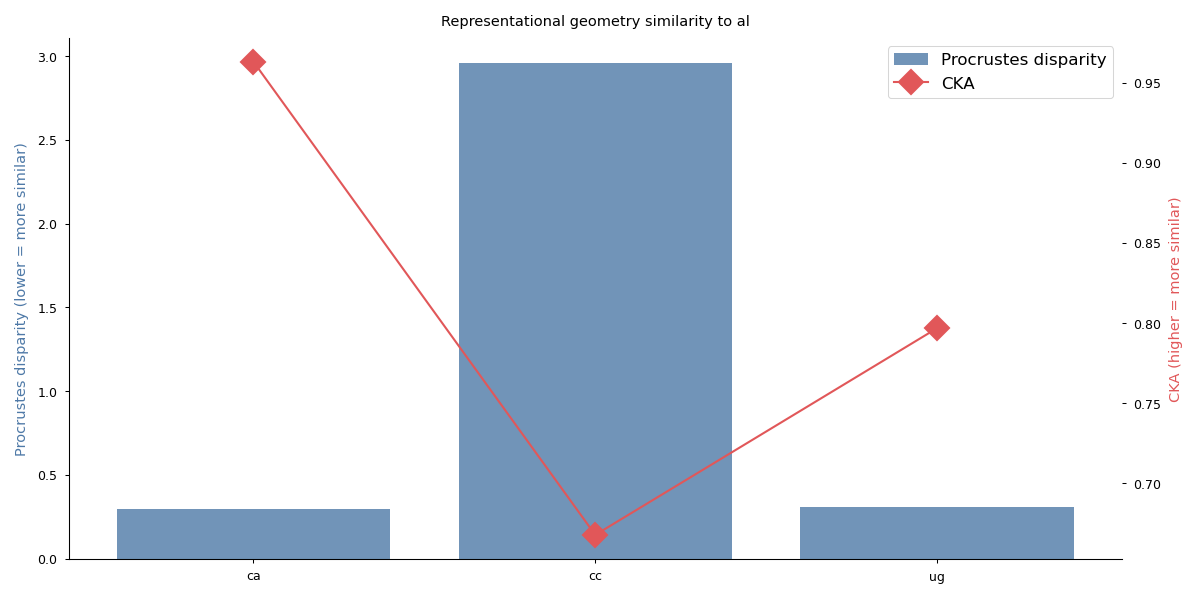

In [6]:
# ── Procrustes alignment: cross-subject geometry comparison ──
if len(SUBJECTS_OK) >= 2:
    # Align all subjects to subject 0
    ref_subj = SUBJECTS_OK[0]
    disparities = {}
    cka_vals = {}

    for subj in SUBJECTS_OK[1:]:
        Z_ref = Z_cond_by_subj[ref_subj]
        Z_s = Z_cond_by_subj[subj]
        # Match dimensions
        d_min = min(Z_ref.shape[1], Z_s.shape[1])
        result_proc = procrustes_align(Z_ref[:, :d_min], Z_s[:, :d_min])
        disparities[subj] = result_proc['disparity']
        cka_vals[subj] = centered_kernel_alignment(Z_ref[:, :d_min], Z_s[:, :d_min])
        print(f"[{ref_subj} → {subj}] Procrustes disparity: {disparities[subj]:.3f}, "
              f"CKA: {cka_vals[subj]:.3f}")

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    subjs = list(disparities.keys())
    ax.bar(subjs, list(disparities.values()), color='#4E79A7', alpha=0.8, label='Procrustes disparity')
    ax2 = ax.twinx()
    ax2.plot(subjs, list(cka_vals.values()), 'D-', color='#E15759', ms=8, label='CKA')
    ax.set_ylabel('Procrustes disparity (lower = more similar)', color='#4E79A7')
    ax2.set_ylabel('CKA (higher = more similar)', color='#E15759')
    ax.set_title(f'Representational geometry similarity to {ref_subj}')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    plt.tight_layout()
    plt.savefig('../results/07_procrustes_alignment.pdf', bbox_inches='tight')
    plt.show()

In [7]:
# Load-dependent RDM variability: is 2-back geometry more stereotyped than 0-back?
load_rdms = {}

for subj in SUBJECTS_OK:
    labels = labels_by_subj[subj]

    for load in [0, 2]:
        mask = labels == load
        if mask.sum() < 5:
            continue
        Z_load = Z_maint_by_subj[subj][mask]   # (N_load, k) — already in latent space
        n_samp = min(20, len(Z_load))
        rdm_trial = representational_dissimilarity_matrix(Z_load[:n_samp], metric="correlation")
        load_rdms[f"{subj}_load{load}"] = rdm_trial

print("Load-specific RDM variability (higher inter-subject RSA = more stereotyped):")
for load in [0, 2]:
    rdm_stack_load = np.array([
        load_rdms[f"{s}_load{load}"]
        for s in SUBJECTS_OK
        if f"{s}_load{load}" in load_rdms
    ])
    if len(rdm_stack_load) >= 2:
        rdm_pairs = [
            rsa_compare(rdm_stack_load[i], rdm_stack_load[j])
            for i in range(len(rdm_stack_load))
            for j in range(i + 1, len(rdm_stack_load))
        ]
        print(f"  {load}-back: mean cross-subj RSA = {np.mean(rdm_pairs):.3f} "
              f"(SD={np.std(rdm_pairs):.3f}, N_pairs={len(rdm_pairs)})")


Load-specific RDM variability (higher inter-subject RSA = more stereotyped):
  0-back: mean cross-subj RSA = 0.144 (SD=0.098, N_pairs=6)
  2-back: mean cross-subj RSA = -0.018 (SD=0.074, N_pairs=6)


In [8]:
# Save results
results_07 = {
    "subjects":            SUBJECTS_OK,
    "maintenance_window":  MAINT_WIN,
    "n_latent_dims":       list(Z_maint_by_subj.values())[0].shape[1] if Z_maint_by_subj else 0,
}

if len(SUBJECTS_OK) >= 2:
    results_07.update({
        "cross_subject_rsa": {
            "pairwise_r":       result["pairwise_r"].tolist(),
            "mean_pairwise_r":  float(result["mean_pairwise_r"]),
            "subjects":         SUBJECTS_OK,
        },
        "noise_ceiling": {"lower": float(nc_lower), "upper": float(nc_upper)},
        "load_model_rsa": float(rsa_load),
        "procrustes": {
            subj: {"disparity": float(d), "cka": float(cka_vals[subj])}
            for subj, d in disparities.items()
        } if "disparities" in dir() else {},
    })

import json
with open(RESULTS / "07_rsa_results.json", "w") as f:
    json.dump(results_07, f, indent=2)
print("Saved → results/07_rsa_results.json")


Saved → results/07_rsa_results.json
